<a href="https://colab.research.google.com/github/RAVIAPTISWETHA/COVID-19-Detection-from-Chest-X-ray-Images-Using-CNN-/blob/main/Data_Loading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import os
from PIL import Image
import random
import hashlib
import shutil
import cv2

print("Libraries imported successfully.")

Libraries imported successfully.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset Path and Folder Check


In [4]:
dataset_path = "/content/drive/MyDrive/Covid19-Pneumonia-Normal Chest X-Ray Images Dataset"

print("Folders inside dataset:\n")
print(os.listdir(dataset_path))

Folders inside dataset:

['COVID', 'PNEUMONIA', 'NORMAL']


# Count Images in Each Class

In [5]:
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} images")

COVID: 1626 images
PNEUMONIA: 1800 images
NORMAL: 1802 images


# Check for Corrupted Images


In [6]:
corrupted = []

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)

print("Number of corrupted images:", len(corrupted))

Number of corrupted images: 0


# Check for Duplicate Images


In [7]:
hash_dict = {}
duplicate_pairs = []
class_duplicates = {}

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)
    duplicate_count = 0

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        with open(img_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in hash_dict:
            duplicate_pairs.append((hash_dict[file_hash], img_path))
            duplicate_count += 1
        else:
            hash_dict[file_hash] = img_path

    class_duplicates[cls] = duplicate_count

# Print duplicate count per class
print("Duplicate Images per Class:\n")
for cls, count in class_duplicates.items():
    print(f"{cls}: {count}")

print("\nTotal duplicate pairs:", len(duplicate_pairs))

Duplicate Images per Class:

COVID: 89
PNEUMONIA: 9
NORMAL: 131

Total duplicate pairs: 229


# Show Sample Duplicate Images


Showing sample duplicate images...



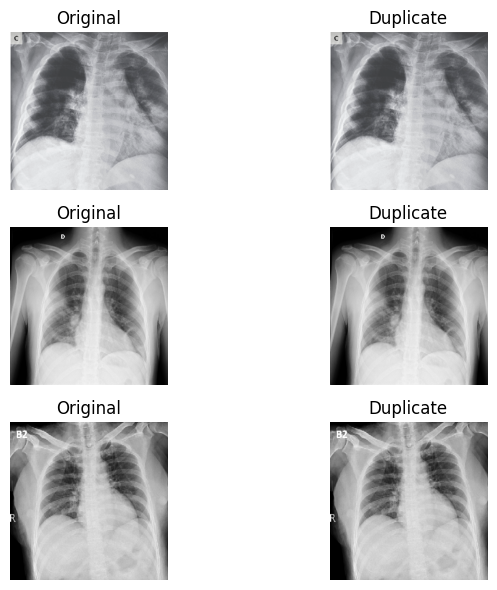

In [8]:
print("\nShowing sample duplicate images...\n")

plt.figure(figsize=(8,6))

for i, (img1_path, img2_path) in enumerate(duplicate_pairs[:3]):

    img1 = Image.open(img1_path)
    img2 = Image.open(img2_path)

    plt.subplot(3, 2, i*2 + 1)
    plt.imshow(img1)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3, 2, i*2 + 2)
    plt.imshow(img2)
    plt.title("Duplicate")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Remove Duplicate Images


In [14]:
clean_dataset_path = "/content/drive/MyDrive/clean_dataset"
duplicates_path = "/content/drive/MyDrive/duplicate_images"

classes = ["COVID", "NORMAL", "PNEUMONIA"]


def is_already_processed(path, classes):
    if not os.path.exists(path):
        return False

    for cls in classes:
        class_path = os.path.join(path, cls)
        if not os.path.exists(class_path) or len(os.listdir(class_path)) == 0:
            return False
    return True


if is_already_processed(clean_dataset_path, classes):
    print("Dataset already cleaned. Skipping processing.")
else:
    print("Processing dataset (removing duplicates)...")

    # Create folders
    for cls in classes:
        os.makedirs(os.path.join(clean_dataset_path, cls), exist_ok=True)
        os.makedirs(os.path.join(duplicates_path, cls), exist_ok=True)

    hash_dict = {}
    duplicates_count = 0

    for cls in classes:
        class_path = os.path.join(dataset_path, cls)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            with open(img_path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            # Unique → clean dataset
            if file_hash not in hash_dict:
                hash_dict[file_hash] = img_path
                shutil.copy(img_path, os.path.join(clean_dataset_path, cls, img_name))

            # Duplicate → separate folder
            else:
                shutil.copy(img_path, os.path.join(duplicates_path, cls, img_name))
                duplicates_count += 1

    print("Done")
    print("Duplicates moved:", duplicates_count)

Dataset already cleaned. Skipping processing.


# Updated Class Counts


In [11]:
print("\nCleaned Dataset Distribution:\n")

class_counts = {}
total_images = 0

for cls in os.listdir(clean_dataset_path):
    class_path = os.path.join(clean_dataset_path, cls)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[cls] = count   # 👈 store in dictionary
        total_images += count
        print(f"{cls}: {count}")

print("\nTotal images:", total_images)


Cleaned Dataset Distribution:

COVID: 1537
NORMAL: 1671
PNEUMONIA: 1791

Total images: 4999


# Display Sample Images

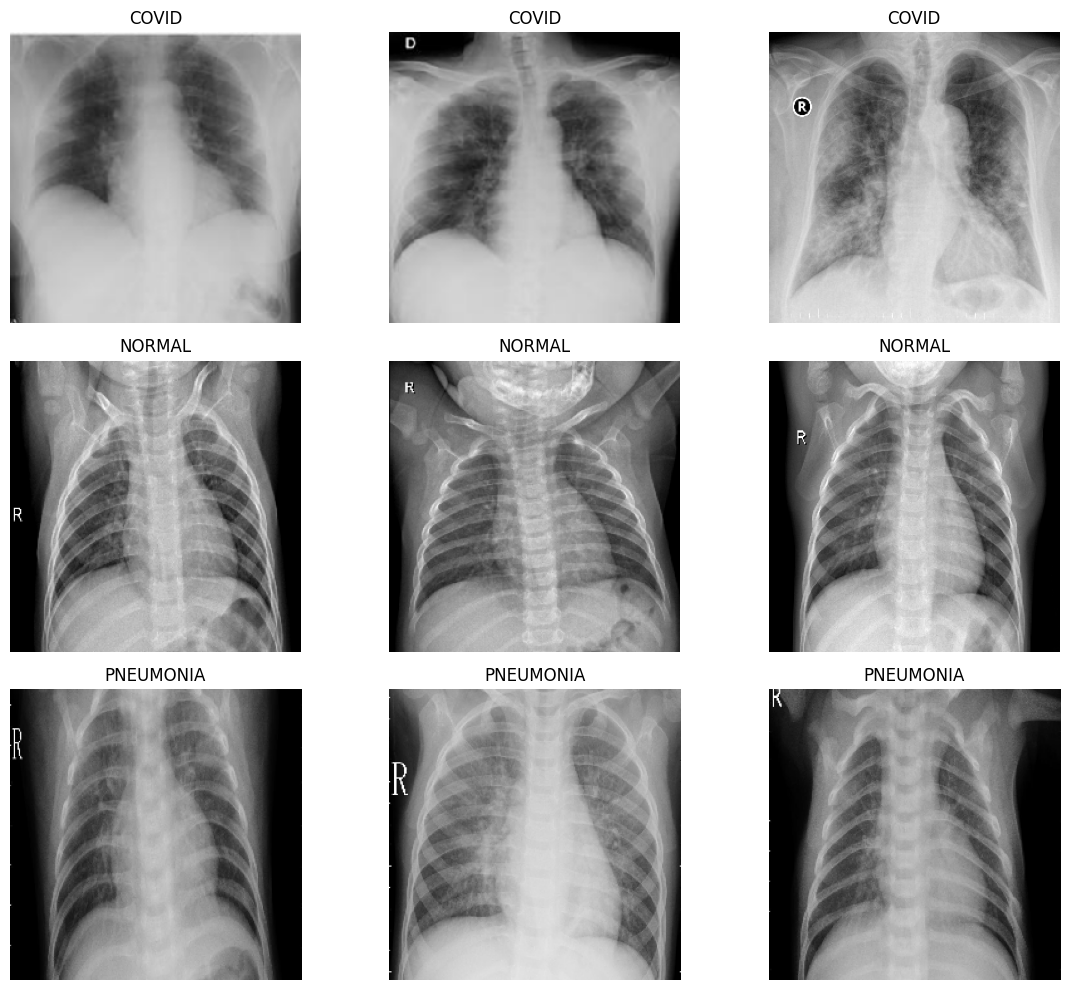

In [13]:
classes = ["COVID", "NORMAL", "PNEUMONIA"]

plt.figure(figsize=(12,10))

plot_index = 1

for cls in classes:
    class_path = os.path.join(clean_dataset_path, cls)

    images = [img for img in os.listdir(class_path) if img.endswith(('.png', '.jpg', '.jpeg'))]

    sample_images = random.sample(images, 3)

    for img_name in sample_images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert("RGB")

        plt.subplot(3, 3, plot_index)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

        plot_index += 1

plt.tight_layout()
plt.show()